# Don't classify. Hallucinate.

*Cheap LLM classification into a taxonomy too large to fit in a prompt — with Couchbase Vector Search doing the resolution step.*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/omnifroodle/couchbase_notebooks/blob/main/notebooks/01_hypothetical_classification.ipynb)
[![Open in GitHub Codespaces](https://github.com/codespaces/badge.svg)](https://codespaces.new/omnifroodle/couchbase_notebooks?quickstart=1)

Classifying text into a controlled vocabulary is the most boring, most common LLM task in
search: given a query or a product title, which of our categories does it belong to?

The obvious approach is to put the vocabulary in the prompt and constrain the output to it.
That works until the vocabulary gets real. Wayfair's product taxonomy — the one in this
notebook — has **1,623 category paths**. Shipping it on every request costs tens of
thousands of tokens per call, and hits the size limits on structured-output schemas.

[Doug Turnbull's suggestion](https://softwaredoug.com/blog/2026/08/10/hypothetical-classifications):
**don't send the vocabulary at all.** Ask a small, cheap model to *invent* the category path
it would expect to exist, then snap that invented path to the nearest real one with an
embedding lookup. The hallucination is the point — it produces a string shaped like a
taxonomy path, which lands in roughly the right neighbourhood of embedding space, and a
vector index does the rest.

It's the same trick as [HyDE](https://arxiv.org/abs/2212.10496) for retrieval, pointed at
classification: generate a plausible fake, then retrieve against it.

**What this notebook does**

1. Loads the 1,623-path WANDS taxonomy and stores it in Couchbase with embeddings.
2. Builds a Search vector index over it.
3. Asks a small model to hallucinate a category path for a product — with none of the real
   taxonomy in the prompt.
4. Resolves the hallucination to a real path with a vector search.
5. **Measures it** against a direct-embedding baseline on held-out products with known
   categories.
6. Uses the resolved category as a filter on a product search, which is what you'd actually
   do with it.

**Requires.** couchbase · llm · local-embeddings

**You need:** a Couchbase Capella cluster (free tier is fine — see
[`docs/capella-setup.md`](../docs/capella-setup.md)) and an API key for any OpenAI-compatible
model endpoint.

**Data:** [WANDS](https://github.com/wayfair/WANDS) (Wayfair, MIT licence) — 43k real product
listings filed under a real, messy retail taxonomy.

In [1]:
# --- Setup. Works in a local checkout and on Colab. -------------------------
import os
import pathlib
import subprocess
import sys

# Cloned on Colab, where there is no local checkout. Override to test a fork.
REPO_URL = os.environ.get("CBNB_REPO_URL", "https://github.com/omnifroodle/couchbase_notebooks")

try:
    import cbnb
except ModuleNotFoundError:
    here = pathlib.Path.cwd()
    root = next((p for p in [here, *here.parents] if (p / "cbnb" / "__init__.py").exists()), None)
    if root is None:
        # Colab: clone the repo so the committed datasets come with it.
        subprocess.check_call(["git", "clone", "--depth", "1", "--quiet", REPO_URL, "cbnb-repo"])
        root = pathlib.Path("cbnb-repo").resolve()
    sys.path.insert(0, str(root))
    import cbnb

# Installs anything missing, loads .env / Colab secrets, and reports what it found.
settings = cbnb.bootstrap(extras=["local-embeddings", "plots"])

cbnb ready (local, autoreload on). Couchbase: cb.***.cloud.couchbase.com (bucket 'demos') | LLM: nanogpt/z-ai/glm-5.3 | embeddings: local


## 1. The vocabulary problem

WANDS ships the category path every product was actually filed under. Here is the shape of it.

In [2]:
from cbnb.datasets import load_wands_products, load_wands_taxonomy, Taxonomy

taxonomy = Taxonomy(load_wands_taxonomy())
products = load_wands_products()

print(f"{len(taxonomy):,} category paths across {len(taxonomy.departments())} departments")
print(f"{len(products):,} products in the committed sample\n")
for path in list(taxonomy)[300:305]:
    print(" ", path)

1,623 category paths across 55 departments
2,500 products in the committed sample

  Décor & Pillows / Picture Frames & Albums / Photo Albums / 4" X 6" Photo Albums
  Décor & Pillows / Seasonal Décor / Fall Décor / Fall Decorative Accents / Banners & Signs Fall Decorative Accents
  Décor & Pillows / Seasonal Décor / Fall Décor / Fall Decorative Accents / NA Fall Decorative Accents
  Décor & Pillows / The Monogram Shop / Monogram Beverage Servers / Carafe Monogram Beverage Servers
  Décor & Pillows / Wall Décor / Memo Boards


In [3]:
# What would it cost to put the whole thing in the prompt?
vocabulary_text = "\n".join(taxonomy.paths)
approx_tokens = len(vocabulary_text) / 4  # rough, but the order of magnitude is the point

print(f"Full taxonomy: {len(vocabulary_text):,} characters ~= {approx_tokens:,.0f} tokens")
print(f"Per 10,000 classifications: ~{approx_tokens * 10_000 / 1e6:,.0f}M prompt tokens,")
print("before you have said a single word about the product you want classified.")

Full taxonomy: 140,882 characters ~= 35,220 tokens
Per 10,000 classifications: ~352M prompt tokens,
before you have said a single word about the product you want classified.


That's the tax on the obvious approach — paid on every single call, for a list that never
changes. Prompt caching helps, and a big enough context window makes it *possible*, but you
are still paying to re-read a static document to answer a five-word question.

So: don't send it.

## 2. Put the vocabulary in Couchbase instead

Each category path becomes a document with an embedding. The vocabulary lives in the
database, where a vector index can search it in a millisecond, instead of in the prompt,
where it costs money every time.

`Embedder` defaults to a local `all-MiniLM-L6-v2` — no API key, 384 dimensions, and it
encodes all 1,623 paths in a few seconds. Vectors come back L2-normalised, so the
`dot_product` similarity the index uses is a cosine similarity.

In [4]:
from cbnb.embeddings import Embedder

embedder = Embedder()          # backend="api" to use your provider's /embeddings instead
print(embedder, "->", embedder.dims, "dimensions")

category_vectors = embedder.encode(taxonomy.paths, progress=True)
category_vectors.shape

Embedder(backend='local', model='sentence-transformers/all-MiniLM-L6-v2', dims=384) -> 384 dimensions


(1623, 384)

In [5]:
from cbnb.couchbase_io import connect, ensure_collection, upsert_docs

BUCKET = settings.cb_bucket
SCOPE = "hypothetical_classification"

cluster = connect(settings)
categories = ensure_collection(cluster, BUCKET, SCOPE, "categories")
print(f"Connected. Writing to {BUCKET}.{SCOPE}.categories")

Connected. Writing to demos.hypothetical_classification.categories


In [6]:
category_docs = {
    f"cat::{i:04d}": {
        "path": path,
        "leaf": taxonomy.leaf(path),
        "department": taxonomy.top_level(path),
        "depth": len(taxonomy.segments(path)),
        "embedding": category_vectors[i].tolist(),
    }
    for i, path in enumerate(taxonomy.paths)
}

upsert_docs(categories, category_docs)

  upserted 200/1623

  upserted 400/1623

  upserted 600/1623

  upserted 800/1623

  upserted 1000/1623

  upserted 1200/1623

  upserted 1400/1623

  upserted 1600/1623

  upserted 1623/1623

1623

### The vector index

A scope-level Search index with one `vector` field and a couple of `keyword` fields for
filtering. `wait_for_index` blocks until ingestion catches up — Search indexing is
asynchronous, and without the wait the first query in a fresh run quietly returns nothing.

In [7]:
from cbnb.couchbase_io import ensure_vector_index, wait_for_index

CATEGORY_INDEX = "categories-vec"

ensure_vector_index(
    cluster,
    bucket_name=BUCKET, scope_name=SCOPE, collection_name="categories",
    index_name=CATEGORY_INDEX,
    vector_field="embedding", dims=embedder.dims,
    text_fields=["leaf"], keyword_fields=["path", "department"],
)
wait_for_index(cluster, bucket_name=BUCKET, scope_name=SCOPE,
               index_name=CATEGORY_INDEX, expected=len(category_docs))

  indexed 1623/1623 (ready)   

  indexed 1623/1623 (ready)   

1623

## 3. Ask a small model to make something up

Now the interesting part. The prompt describes the *shape* of a category path — depth,
separator, capitalisation, the general register of a home-goods retailer — and says nothing
about which categories exist. The model is explicitly told to invent one.

Note what is not in this prompt: the taxonomy.

In [8]:
from pydantic import BaseModel, Field
from cbnb.llm import LLM

llm = LLM()   # provider/model come from CBNB_LLM_PROVIDER / CBNB_LLM_MODEL
print(llm)


class HypotheticalCategory(BaseModel):
    """A category path the model believes a home-goods retailer would use."""
    department: str = Field(description="Top-level department, e.g. 'Furniture'")
    category_path: str = Field(
        description="Full path from department to leaf, joined by ' / ', 3-5 levels deep"
    )


CLASSIFY_SYSTEM = """\
You file products into the category taxonomy of a large home-goods retailer.

You do not have the taxonomy. Invent the category path you would expect it to contain.

Rules:
- 3 to 5 levels, most general first, joined by " / ".
- Level 1 is a department: Furniture, Outdoor, Lighting, Bed & Bath, Kitchen & Tabletop,
  Storage & Organization, Decor & Pillows, Appliances, Baby & Kids, Rugs, Pet, and so on.
- Each level narrows the one before it. The last level is the most specific.
- Use plural, title-cased retail category names ("Coffee Tables", not "a brown coffee table").
- Categories describe the kind of product, never its colour, material, brand or size.
- Output the path only. Do not explain."""


def imagine_category(product_name: str) -> HypotheticalCategory:
    return llm.structured(
        f"Product: {product_name}",
        HypotheticalCategory,
        system=CLASSIFY_SYSTEM,
    )


for name in ["brown coffee table",
             "solid wood platform bed",
             "outdoor propane fire pit table",
             "kids dinosaur night light"]:
    guess = imagine_category(name)
    print(f"{name:38s} -> {guess.category_path}")

LLM(provider='nanogpt', model='z-ai/glm-5.3')


brown coffee table                     -> Furniture / Living Room Furniture / Coffee Tables


solid wood platform bed                -> Furniture / Bedroom Furniture / Beds / Platform Beds


outdoor propane fire pit table         -> Outdoor / Fire Pits & Chimineas / Fire Pit Tables


kids dinosaur night light              -> Baby & Kids / Kids Decor / Night Lights


Those paths are plausible and mostly **wrong** — they are not in the taxonomy. That is
fine. They are wrong in a very particular way: they are wrong the way a *category path* is
wrong, not the way a product title is wrong. Which makes them easy to fix.

## 4. Resolve the hallucination against Couchbase

One vector search per classification. The invented path is embedded and matched against the
1,623 real ones; the nearest neighbour is the answer.

In [9]:
from cbnb.couchbase_io import vector_search


def resolve(text: str, k: int = 1):
    """Nearest real category path(s) to an arbitrary string."""
    return vector_search(
        cluster,
        bucket_name=BUCKET, scope_name=SCOPE, index_name=CATEGORY_INDEX,
        vector_field="embedding",
        query_vector=embedder.encode_one(text),
        k=k, fields=["path", "department"], num_candidates=max(k * 4, 20),
    )


def classify(product_name: str) -> dict:
    """Hallucinate, then resolve."""
    guess = imagine_category(product_name)
    hit = resolve(guess.category_path)[0]
    return {"product": product_name,
            "hallucinated": guess.category_path,
            "resolved": hit["path"],
            "score": hit.score}


import pandas as pd

demo = pd.DataFrame([classify(n) for n in [
    "brown coffee table",
    "solid wood platform bed",
    "outdoor propane fire pit table",
    "kids dinosaur night light",
    "stainless steel over the door towel rack",
]])
demo.style.hide(axis="index")

product,hallucinated,resolved,score
brown coffee table,Furniture / Living Room Furniture / Coffee Tables,Furniture / Living Room Furniture / Coffee Tables & End Tables / Coffee Tables,0.945160
solid wood platform bed,Furniture / Bedroom Furniture / Beds / Platform Beds,Furniture / Bedroom Furniture / Beds & Headboards / Beds,0.900796
outdoor propane fire pit table,Outdoor / Fire Pits & Outdoor Heating / Fire Pit Tables,Outdoor / Outdoor Heating / Fire Pits / Natural Gas Fire Pits,0.863826
kids dinosaur night light,Baby & Kids / Kids Decor / Night Lights / Character Night Lights,Baby & Kids / Baby & Kids Décor & Lighting / Baby Mobiles,0.721161
stainless steel over the door towel rack,Bed & Bath / Bathroom Hardware / Towel Racks & Hooks / Over-the-Door Towel Racks,Bed & Bath / Shower Curtains & Accessories / Shower Curtain Hooks,0.743851


Look at the brown coffee table: the invented path isn't in the taxonomy, but it resolves to
the real `Furniture / Living Room Furniture / Coffee Tables & End Tables / Coffee Tables` —
a string the model never saw.

Not every row lands. Some resolve to a category that is close in embedding space and wrong
on the shelf — in the run stored here, an over-the-door towel *rack* resolves to *Bath
Towels*, and it has the lowest score in the table. A weak score is a useful hint that a
resolution is shaky, and the hook for refining uncertain results (see *Where to take
this*).

## 5. Does it actually beat the obvious baseline?

The obvious baseline needs no LLM at all: embed the product title and find the nearest
category path. If that works as well, the LLM call is waste.

WANDS gives us ground truth — every product's real category path — so this is measurable.
Three numbers, because a hierarchical taxonomy makes "nearly right" meaningful:

- **exact** — the full path matches
- **department** — the top level matches
- **prefix overlap** — fraction of the true path's levels matched from the root

`N_EVAL` is the only knob that costs money. At 150 products the department and
prefix-overlap gaps are clear. Exact-path accuracy is noisier: only a small share of products
match exactly and the model's output varies between runs, so a handful of products moves
that number by several points. Raise `N_EVAL` if exact matches are what you care about.

In [10]:
N_EVAL = 150

sample = products.sample(N_EVAL, random_state=1729).reset_index(drop=True)
names = sample["product_name"].tolist()
truth = sample["category_hierarchy"].tolist()

# Baseline: embed the product title, take the nearest category. No LLM.
baseline = [hits[0]["path"] for hits in
            (resolve(n) for n in names)]

# Method: hallucinate a path, then resolve it. Concurrent, because 150 serial
# API calls is a coffee break.
guesses = llm.map(names, imagine_category, max_workers=8)
method = [resolve(g.category_path)[0]["path"] for g in guesses]

print("done")

  25/150

  50/150

  75/150

  100/150

  125/150

  150/150

done


In [11]:
def score(predictions, label):
    exact = sum(p == t for p, t in zip(predictions, truth)) / len(truth)
    dept = sum(taxonomy.top_level(p) == taxonomy.top_level(t)
               for p, t in zip(predictions, truth)) / len(truth)
    overlap = sum(taxonomy.prefix_overlap(p, t) for p, t in zip(predictions, truth)) / len(truth)
    return {"method": label, "exact path": exact, "department": dept, "prefix overlap": overlap}


results = pd.DataFrame([
    score(baseline, "embed the title (no LLM)"),
    score(method, "hallucinate -> resolve"),
]).set_index("method")

results.style.format("{:.1%}").set_caption(f"n = {N_EVAL} WANDS products")

,exact path,department,prefix overlap
method,,,
embed the title (no LLM),16.7%,48.7%,37.0%
hallucinate -> resolve,26.0%,69.3%,54.5%


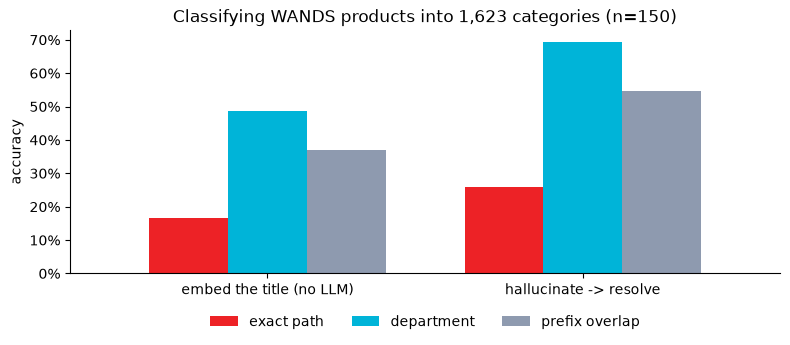

In [12]:
import matplotlib.pyplot as plt

ax = results.plot.bar(rot=0, figsize=(8, 3.6), width=0.75,
                      color=["#ED2226", "#00B4D8", "#8E9AAF"])
ax.set_ylabel("accuracy")
ax.set_xlabel("")
ax.set_title(f"Classifying WANDS products into 1,623 categories (n={N_EVAL})")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

### Where each method goes wrong

Worth looking at, because the two methods fail differently.

In [13]:
comparison = pd.DataFrame({
    "product": names,
    "true": truth,
    "baseline": baseline,
    "hallucinated": [g.category_path for g in guesses],
    "resolved": method,
})
comparison["baseline_ok"] = comparison["true"] == comparison["baseline"]
comparison["method_ok"] = comparison["true"] == comparison["resolved"]

fixed = comparison[comparison["method_ok"] & ~comparison["baseline_ok"]]
print(f"{len(fixed)} the LLM got right and the baseline did not:\n")
for _, row in fixed.head(4).iterrows():
    print(f"  {row['product']}")
    print(f"    baseline : {row['baseline']}")
    print(f"    imagined : {row['hallucinated']}")
    print(f"    resolved : {row['resolved']}  <- correct\n")

23 the LLM got right and the baseline did not:

  zeller sunflower cast iron napkin holder
    baseline : Napkin Rings, Place Card Holders & Food Markers
    imagined : Kitchen & Tabletop / Tabletop Accessories / Napkin Holders
    resolved : Kitchen & Tabletop / Kitchen Organization / Countertop & Sink Organization / Paper Towel & Napkin Holders  <- correct

  single handle 0.75 '' thermostatic shower valve
    baseline : Shower Curtain Rods
    imagined : Bed & Bath / Bathroom Hardware / Shower Valves / Thermostatic Shower Valves
    resolved : Home Improvement / Bathroom Remodel & Bathroom Fixtures / Showers & Bathtubs / Showers & Bathtubs Plumbing / Valves / Shower Valves  <- correct

  yann antique console table
    baseline : Furniture / Living Room Furniture / Console Tables / Brown Console Tables
    imagined : Furniture / Living Room Furniture / Accent Tables / Console Tables
    resolved : Furniture / Living Room Furniture / Console Tables  <- correct

  honey bee signature n

In [14]:
broke = comparison[~comparison["method_ok"] & comparison["baseline_ok"]]
print(f"{len(broke)} the baseline got right and the LLM did not:\n")
for _, row in broke.head(4).iterrows():
    print(f"  {row['product']}")
    print(f"    true     : {row['true']}")
    print(f"    imagined : {row['hallucinated']}")
    print(f"    resolved : {row['resolved']}\n")

9 the baseline got right and the LLM did not:

  usb mini portable air conditioner
    true     : Home Improvement / Heating, Cooling & Air Quality / Cooling / Air Conditioners / Portable Air Conditioners
    imagined : Appliances / Heating & Cooling / Fans / Portable Fans
    resolved : Home Improvement / Heating, Cooling & Air Quality / Cooling / Portable Fans

  mariela resin free standing umbrella base
    true     : Outdoor / Outdoor Shades / Outdoor Umbrellas / Patio Umbrella Stands & Bases / Plastic & Resin Patio Umbrella Stands & Bases
    imagined : Outdoor / Patio Umbrellas & Shades / Umbrella Bases & Stands
    resolved : Outdoor / Outdoor Shades / Outdoor Umbrellas / Patio Umbrella Stands & Bases

  milan 2 ft. x 2 ft. drop-in or glue-up pvc ceiling tile
    true     : Home Improvement / Flooring, Walls & Ceiling / Walls & Ceilings / Ceiling Tiles / Grid Mount Ceiling Tiles
    imagined : Decor & Pillows / Wall & Ceiling Decor / Ceiling Tiles / PVC Ceiling Tiles
    resolve

The pattern: embedding a product title directly puts you in *product* space, where "solid
wood platform bed" sits near other bed descriptions but not especially near the string
`Furniture / Bedroom Furniture / Beds & Headboards / Beds / Twin Beds`. The hallucinated
path is already in *taxonomy* space. The LLM's job is not to know the answer — it's to
translate into the right dialect.

In the run stored here, the misses come in two kinds:

- **Near misses** — the right branch, the wrong leaf. A glass cutting board resolves to the
  parent *Cutting Boards* instead of *Glass Cutting Boards*. Exact-match scoring counts that
  as wrong, which is why prefix overlap is in the table.
- **Retailer filing decisions** — nobody would guess that Wayfair files a coat rack under
  *Contractor / Entry & Hallway*, or PVC ceiling tiles under *Home Improvement* rather than
  décor. No embedding trick recovers a
  convention the model has never seen; this is where a second, grounded pass earns its cost.

## 6. What it cost

In [15]:
u = llm.usage
per_call = u.prompt_tokens / u.calls if u.calls else 0

print(f"Model    : {llm.provider.label} / {llm.model}")
print(f"Usage    : {u}")
if per_call:
    print(f"\nPer classification : ~{per_call:,.0f} prompt tokens")
    print(f"Taxonomy in prompt : ~{approx_tokens:,.0f} prompt tokens "
          f"({approx_tokens / per_call:,.0f}x more, on every single call)")
else:
    print("\nEvery call came from the on-disk cache. Re-run with "
          "LLM(cache=False) to measure real token usage.")

Model    : NanoGPT / z-ai/glm-5.3
Usage    : 159 API calls (0 served from cache), 54,650 prompt + 5,531 completion tokens, 1362.3s

Per classification : ~344 prompt tokens
Taxonomy in prompt : ~35,220 prompt tokens (102x more, on every single call)


The vocabulary moved from a per-call prompt cost to a one-time indexing cost, and the
per-call cost dropped to a short prompt plus one vector search. Add a category and you
upsert one document — you don't touch the prompt, and you don't re-validate a schema.

## 7. What the classification is actually for

A category label is only worth having if it narrows a search. Load the products with their
own embeddings, then run the same vector search three ways: unfiltered, prefiltered to the
resolved department, and prefiltered to the branch of the taxonomy the classification
landed in.

In [16]:
product_vectors = embedder.encode(products["product_name"].tolist(), progress=True)

product_collection = ensure_collection(cluster, BUCKET, SCOPE, "products")
upsert_docs(product_collection, {
    f"prod::{row.product_id}": {
        "product_id": int(row.product_id),
        "name": row.product_name,
        "category_path": row.category_hierarchy,
        "department": taxonomy.top_level(row.category_hierarchy),
        "embedding": product_vectors[i].tolist(),
    }
    for i, row in enumerate(products.itertuples())
})

PRODUCT_INDEX = "products-vec"
ensure_vector_index(
    cluster,
    bucket_name=BUCKET, scope_name=SCOPE, collection_name="products",
    index_name=PRODUCT_INDEX,
    vector_field="embedding", dims=embedder.dims,
    text_fields=["name"], keyword_fields=["category_path", "department"],
)
wait_for_index(cluster, bucket_name=BUCKET, scope_name=SCOPE,
               index_name=PRODUCT_INDEX, expected=len(products))

  upserted 200/2500

  upserted 400/2500

  upserted 600/2500

  upserted 800/2500

  upserted 1000/2500

...

  upserted 2400/2500

  upserted 2500/2500

  indexed 2500/2500 (ready)   

  indexed 2500/2500 (ready)   

2500

In [17]:
import couchbase.search as search

QUERY = "something to keep drinks on next to the sofa"

guess = imagine_category(QUERY)
resolved_path = resolve(guess.category_path)[0]["path"]
department = taxonomy.top_level(resolved_path)
# The resolved category's parent: keeps siblings in play, and a single leaf is
# too narrow to search on its own.
branch = " / ".join(taxonomy.segments(resolved_path)[:-1]) or resolved_path

print(f"query      : {QUERY}")
print(f"imagined   : {guess.category_path}")
print(f"resolved   : {resolved_path}")
print(f"branch     : {branch}")

query_vector = embedder.encode_one(QUERY)


def product_search(prefilter=None, k=5):
    """Top products for the query, labelled with where each one is filed."""
    hits = vector_search(
        cluster,
        bucket_name=BUCKET, scope_name=SCOPE, index_name=PRODUCT_INDEX,
        vector_field="embedding", query_vector=query_vector,
        k=k, fields=["name", "category_path"], num_candidates=100,
        prefilter=prefilter,
    )
    return pd.Series([
        f"{h['name'][:40]}  ({taxonomy.top_level(h['category_path'])} › "
        f"{taxonomy.leaf(h['category_path'])})"
        for h in hits
    ], dtype=object)


pd.DataFrame({
    "no filter": product_search(),
    f"department: {department}": product_search(
        search.TermQuery(department, field="department")),
    f"branch: {taxonomy.leaf(branch)}": product_search(
        search.PrefixQuery(branch, field="category_path")),
}).fillna("").style.hide(axis="index")

query      : something to keep drinks on next to the sofa
imagined   : Furniture / Living Room Furniture / Side Tables
resolved   : Furniture / Living Room Furniture / Coffee Tables & End Tables / End & Side Tables
branch     : Furniture / Living Room Furniture / Coffee Tables & End Tables


no filter,department: Furniture,branch: Coffee Tables & End Tables
eser patio sofa with cushions (Outdoor › Patio Sofas & Sectionals),home theater sofa (Furniture › Theater Seating),coyne coffee table (Furniture › Square Coffee Tables)
home theater sofa (Furniture › Theater Seating),ariana cocktail ottoman (Furniture › Rectangle Ottomans & Poufs),modrest coffee table (Furniture › Round Coffee Tables)
ariana cocktail ottoman (Furniture › Rectangle Ottomans & Poufs),upholstered tufted storage ottoman (Furniture › Square Ottomans & Poufs),pedestal coffee table (Furniture › Oval Coffee Tables)
claremore 95 '' square arm sofa with rev (Sale › Sofas),double chaise lounge sofa floor couch (Furniture › Gaming Chairs),the lord raffles solid wood coffee table (Furniture › Free Form Coffee Tables)
lakewood chaise furniture dog sofa (Pet › All Dog Beds),kinch bar with wine storage (Furniture › Wine Home Bars & Bar Sets),wood 3 piece coffee table set (Furniture › Coffee Table Sets)


Same query vector, same index; only the prefilter changes.

- **No filter** returns whatever sits nearest in embedding space, from any department that
  happens to mention sofas.
- **The department** fixes the department but not the kind of product.
- **The branch** — a `PrefixQuery` on the keyword-indexed `category_path` — returns what the
  shopper was asking for.

The branch is the resolved category's parent rather than the category itself, which keeps
siblings in play and leaves enough products to search: each leaf holds only a couple in this
sample. The classification is what made the filter possible, and it cost one cheap LLM call
and one vector search.

## Where to take this

- **Refine only when retrieval is unsure.** Every resolution comes back with a similarity
  score. When the top hit is strong, take it. When it isn't, go back to Couchbase for a short
  list of *real* candidates — the nearest paths, prefiltered to the resolved department with
  the same `TermQuery` as section 7 — and ask the model a second, narrow question: which of
  these fits? A couple of dozen grounded paths is a cheap prompt where 1,623 was not, and
  products that resolved confidently never pay for the second call. Filter on the
  *resolved* department (`hit["department"]`), not the invented one: the model's
  department is usually right in spirit, but only the resolved one is guaranteed to be a
  value in the index. Tune the score threshold on your own data.
- **Swap in a smaller model.** The whole premise is that this works without a frontier
  model. Set `CBNB_LLM_MODEL` to the cheapest thing your provider offers and re-run
  section 5 — the interesting question is where the accuracy actually falls off.
- **Hallucinate several paths and vote.** Sample the model three times at a higher
  temperature, resolve each, and take the most common real category.
- **Attribute extraction.** The same hallucinate-then-resolve pattern works for colours,
  materials and brands — any controlled vocabulary too big to enumerate.
- **Cache the resolutions.** Store the hallucinated path alongside its resolved category
  in Couchbase and the second occurrence of a near-identical product skips the LLM entirely.

Credit where it's due: the technique is
[Doug Turnbull's](https://softwaredoug.com/blog/2026/08/10/hypothetical-classifications),
and his [`cheat-at-search`](https://github.com/softwaredoug/cheat-at-search) repository has
the original implementation.

In [18]:
# Clean up everything this notebook created. Uncomment to run.
# from cbnb.couchbase_io import drop_demo_data
# drop_demo_data(cluster, BUCKET, SCOPE)